# 03 — Exploratory Data Analysis (EDA)

## Objective
Build a complete behavioral profile of legitimate transactions
and document precisely how each fraud type deviates from that
profile — creating the analytical foundation for feature
engineering and model selection.

## The Detective Mindset
We do not just look at correlations and distributions.
We build FRAUD PROFILES:
- What does a legitimate transaction look like?
- What GPS fingerprint does driver fraud leave?
- What device + account signature does user fraud leave?
- What network pattern does collusion fraud leave?

## Business Questions We Answer
1. How clearly does GPS data separate driver fraud from legitimate?
2. What device signals identify user fraud?
3. What network pattern reveals collusion fraud?
4. Which velocity features are the strongest fraud signals?
5. Do fraud patterns vary by time of day or day of week?
6. Which zones have the highest fraud rates?
7. How does fare anomaly score behave across fraud types?
8. What account characteristics predict fraud?
9. Are there interaction effects between signals?
10. What is the feature correlation structure?

## Two Levels of Analysis
Level 1: Stage 1 analysis — fraud vs legitimate (all ~60,000 rows)
Level 2: Stage 2 analysis — driver vs user vs collusion
         (among fraud rows only — ~1,836 rows)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"]    = 13
plt.rcParams["axes.titleweight"]  = "bold"

FRAUD_COLORS = {
    0: "#4CAF50", 1: "#F44336",
    2: "#FF9800", 3: "#9C27B0"
}
FRAUD_LABELS = {
    0: "Legitimate",    1: "Driver Fraud",
    2: "User Fraud",    3: "Collusion Fraud"
}

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

transactions_df = pd.read_csv(
    PATH + "transactions_clean.csv",
    parse_dates=["txn_timestamp"]
)

print(f"Cleaned transactions loaded ✅")
print(f"  Shape: {transactions_df.shape}")
print(f"\nFraud distribution:")
for k in [0, 1, 2, 3]:
    count = (transactions_df["fraud_label"] == k).sum()
    pct   = count / len(transactions_df) * 100
    print(f"  {FRAUD_LABELS[k]:<20}: {count:>7,}  ({pct:.2f}%)")

# Separate fraud-only for Stage 2 analysis
fraud_only_df = transactions_df[
    transactions_df["is_fraud"] == 1
].copy()
print(f"\nFraud-only dataset for Stage 2 analysis: "
      f"{len(fraud_only_df):,} rows")

Cleaned transactions loaded ✅
  Shape: (60000, 47)

Fraud distribution:
  Legitimate          :  58,169  (96.95%)
  Driver Fraud        :     724  (1.21%)
  User Fraud          :     615  (1.03%)
  Collusion Fraud     :     492  (0.82%)

Fraud-only dataset for Stage 2 analysis: 1,831 rows


## Section 1 — GPS Fraud Fingerprint Analysis

### Question: How clearly does GPS data separate driver fraud?

From Cell 10 of Notebook 01, we already know the direction:
- Driver fraud drives at 137 kmph average
- Driver fraud moves only 0.64 km despite claiming 6+ km
- Driver fraud GPS is suspiciously perfect (0.98 strength)

Now we quantify this precisely and build visual evidence.

This section is the foundation of Stage 1 anomaly detection —
Isolation Forest will learn the "normal GPS envelope" from
legitimate transactions, then flag driver fraud as anomalous
because it falls completely outside that envelope.

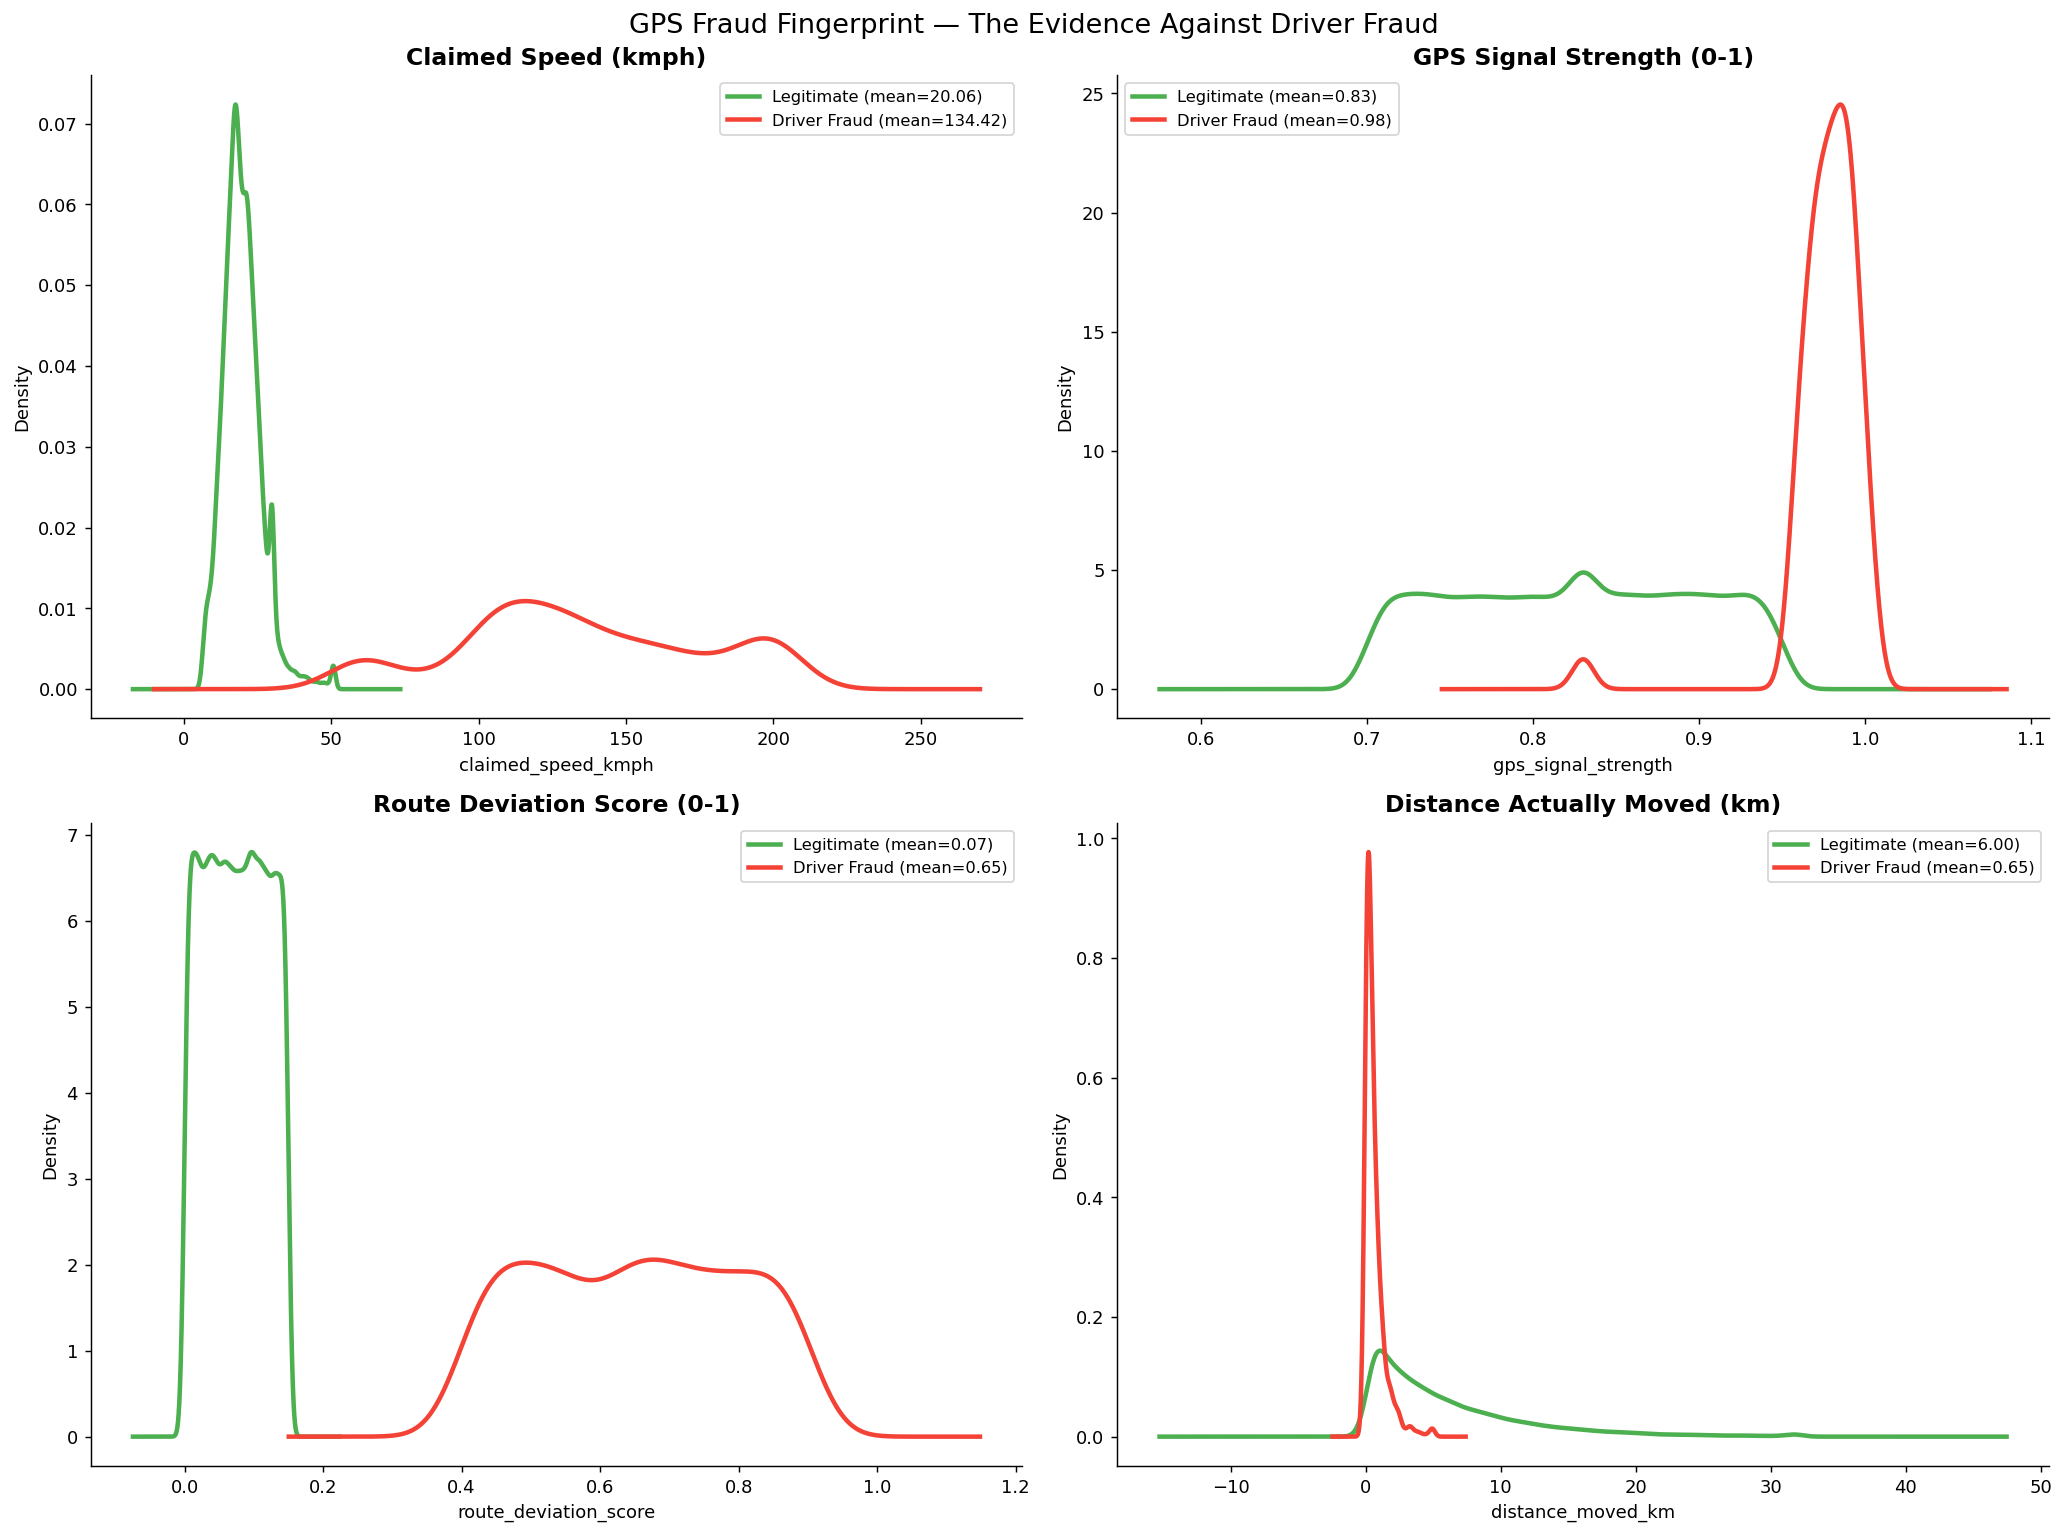

GPS Signal Separation Summary:
Feature                          Legitimate   Driver Fraud    Ratio
--------------------------------------------------------------------
claimed_speed_kmph                   20.063        134.424     6.7x
gps_signal_strength                   0.825          0.977     1.2x
route_deviation_score                 0.075          0.651     8.7x
distance_moved_km                     6.000          0.646     0.1x


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("GPS Fraud Fingerprint — The Evidence Against Driver Fraud",
             fontsize=15)

gps_signals = [
    ("claimed_speed_kmph",   "Claimed Speed (kmph)",          axes[0][0]),
    ("gps_signal_strength",  "GPS Signal Strength (0-1)",     axes[0][1]),
    ("route_deviation_score","Route Deviation Score (0-1)",   axes[1][0]),
    ("distance_moved_km",    "Distance Actually Moved (km)",  axes[1][1]),
]

for col, title, ax in gps_signals:
    if col not in transactions_df.columns:
        continue

    # KDE for legitimate and driver fraud only
    for k in [0, 1]:
        subset = transactions_df[
            transactions_df["fraud_label"] == k
        ][col].dropna()

        # Clip extreme values for visualization only
        clip_val = subset.quantile(0.995)
        subset_clipped = subset.clip(upper=clip_val)

        subset_clipped.plot.kde(
            ax=ax, color=FRAUD_COLORS[k],
            linewidth=2.5,
            label=f"{FRAUD_LABELS[k]} (mean={subset.mean():.2f})"
        )

    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_01_gps_fingerprint.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("GPS Signal Separation Summary:")
print(f"{'Feature':<30} {'Legitimate':>12} {'Driver Fraud':>14} {'Ratio':>8}")
print("-" * 68)
for col, title, _ in gps_signals:
    if col not in transactions_df.columns:
        continue
    legit_mean = transactions_df[
        transactions_df["fraud_label"] == 0
    ][col].mean()
    fraud_mean = transactions_df[
        transactions_df["fraud_label"] == 1
    ][col].mean()
    ratio = fraud_mean / legit_mean if legit_mean > 0 else 0
    print(f"{col:<30} {legit_mean:>12.3f} {fraud_mean:>14.3f} {ratio:>7.1f}x")

## Section 2 — User Fraud Device & Account Signatures

### Question: If GPS cannot detect user fraud, what can?

User fraud GPS is identical to legitimate GPS — the ride
actually happened. The fraud is in the PAYMENT, not the ride.

To detect user fraud, we must look at:
1. Device signals — VPN, multiple accounts, GPS mock
2. Account history — chargebacks, promo abuse, account age
3. Payment behavior — payment failures, disputed charges

This section builds the user fraud profile from these signals.

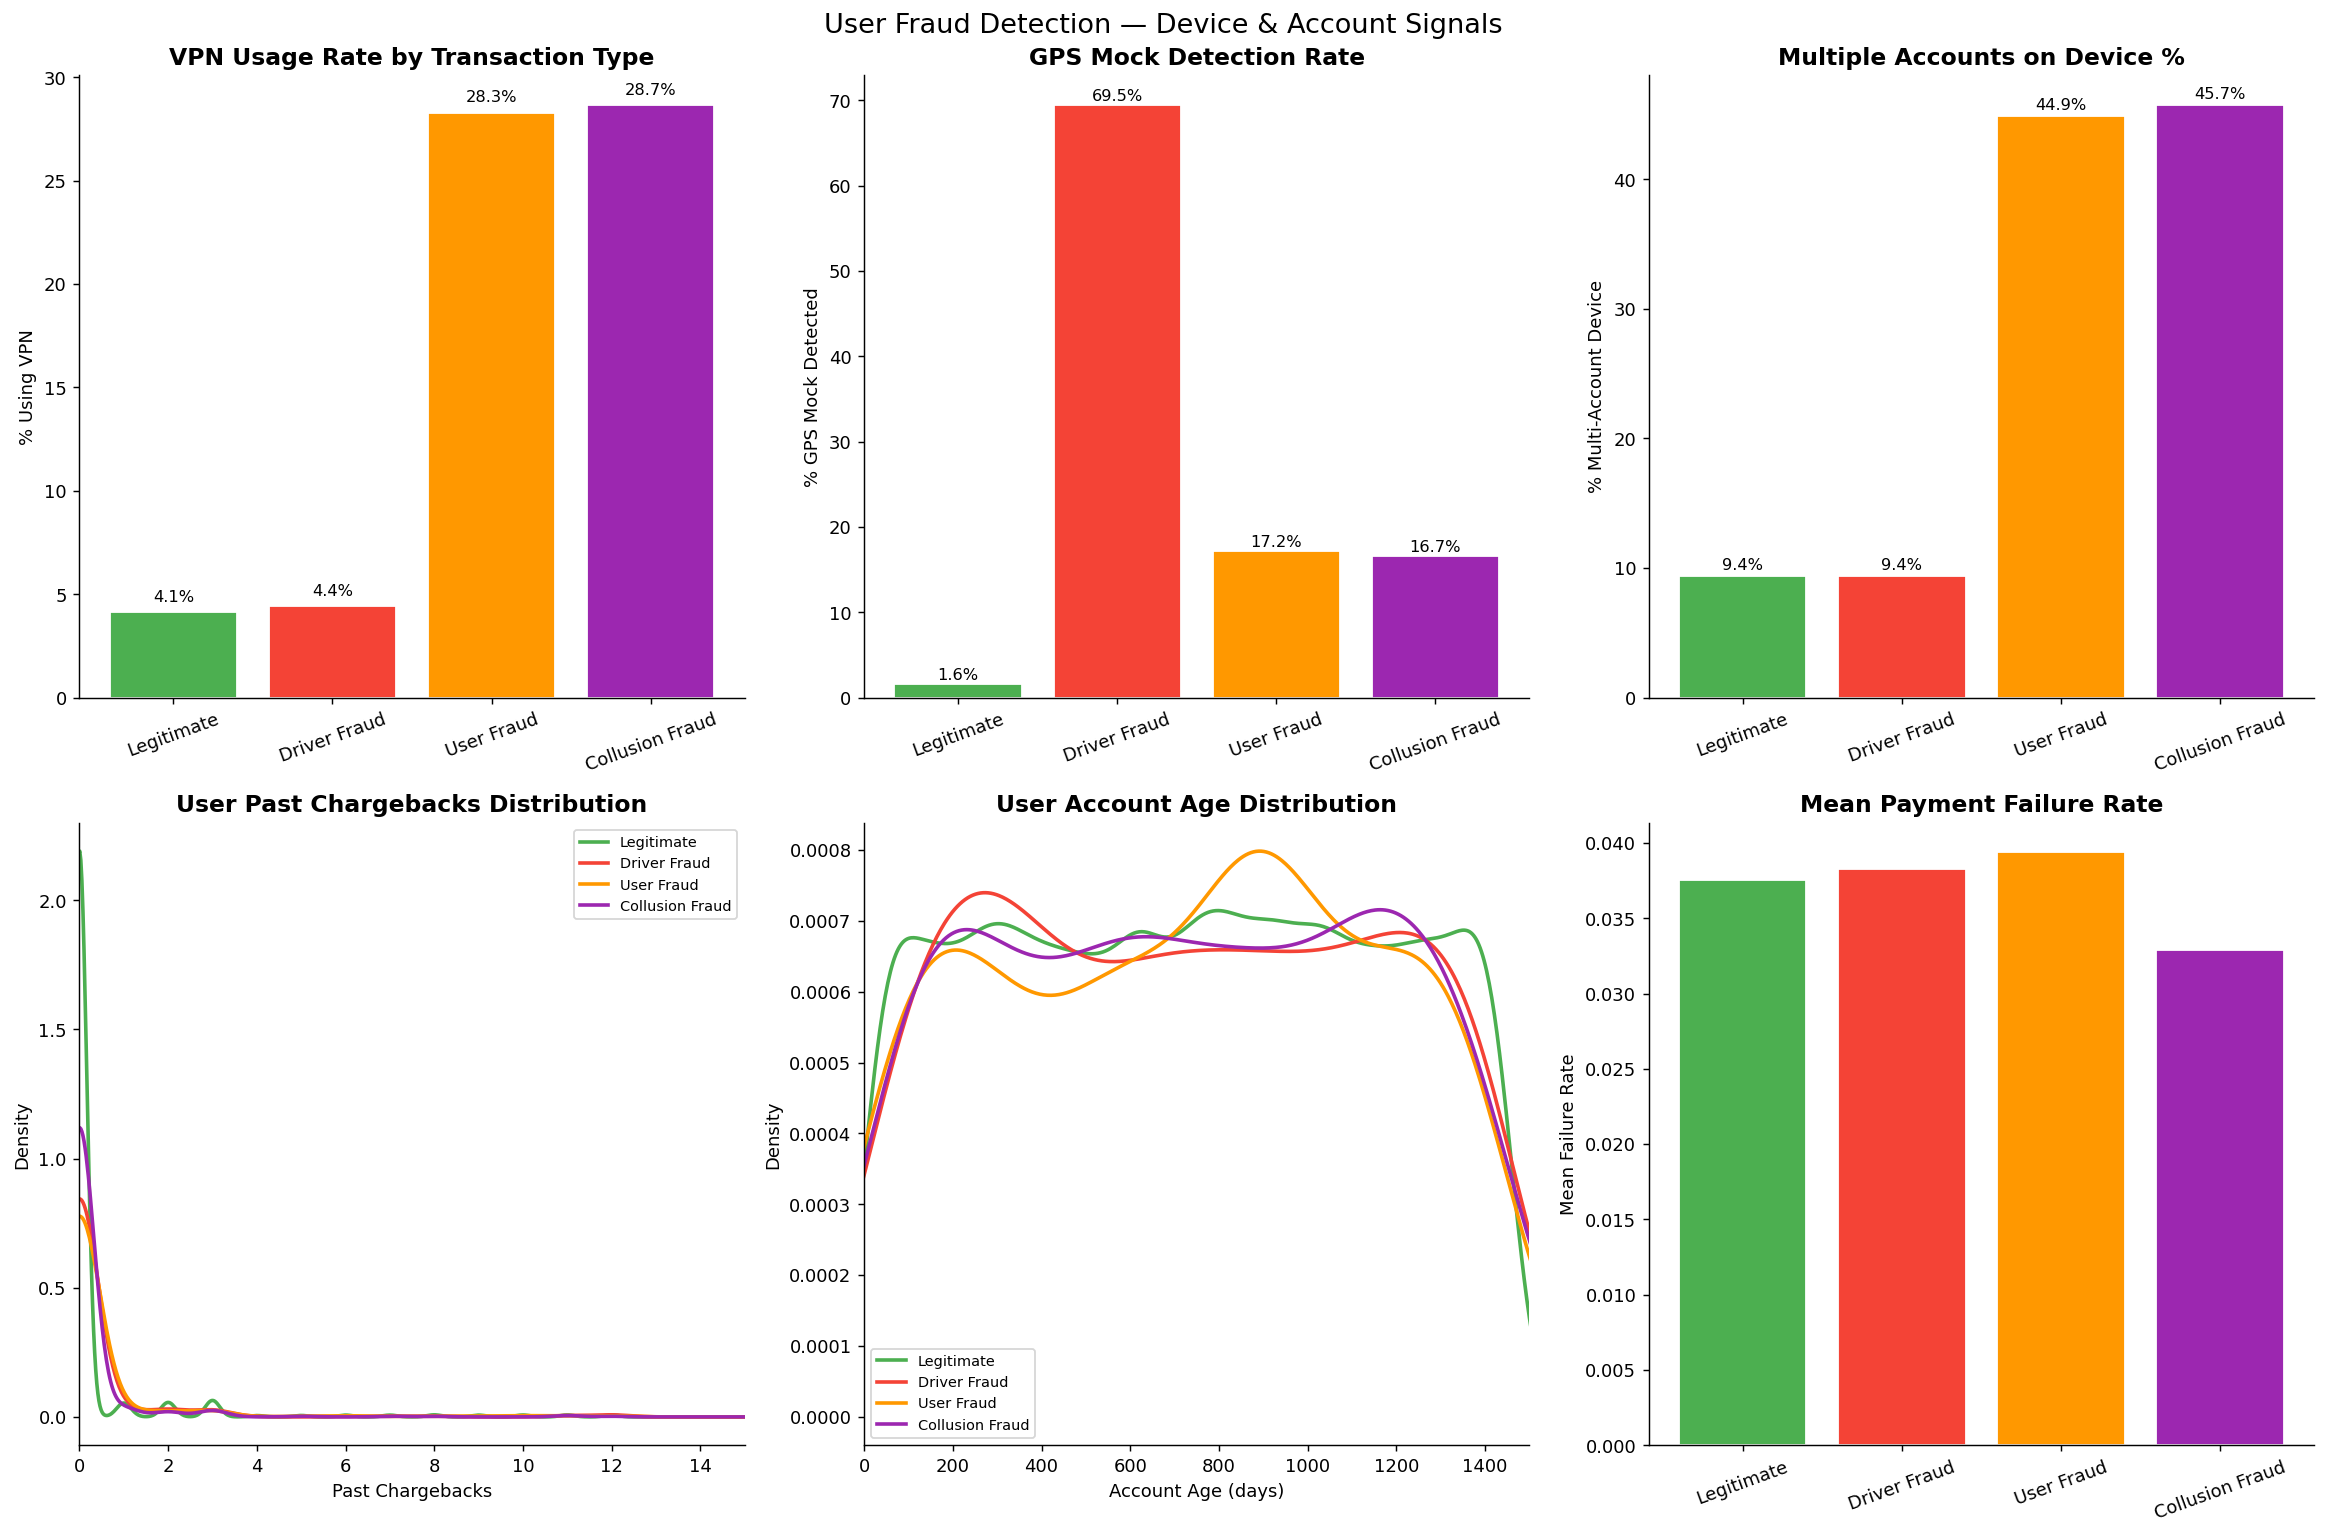

User Fraud Device & Account Summary:
  VPN usage:  Legitimate=4.1%  User Fraud=28.3%
  GPS mock:   Legitimate=1.6%  Driver Fraud=69.5%
  Multi-acct: Legitimate=9.4%  User Fraud=44.9%  Collusion=45.7%


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("User Fraud Detection — Device & Account Signals",
             fontsize=15)

# ── VPN usage by fraud type ───────────────────────────────────
vpn_rates = transactions_df.groupby("fraud_label")[
    "uses_vpn"
].mean() * 100
axes[0][0].bar(
    [FRAUD_LABELS[k] for k in vpn_rates.index],
    vpn_rates.values,
    color=[FRAUD_COLORS[k] for k in vpn_rates.index],
    edgecolor="white"
)
axes[0][0].set_title("VPN Usage Rate by Transaction Type")
axes[0][0].set_ylabel("% Using VPN")
axes[0][0].tick_params(axis="x", rotation=20)
for i, v in enumerate(vpn_rates.values):
    axes[0][0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# ── GPS mock by fraud type ────────────────────────────────────
mock_rates = transactions_df.groupby("fraud_label")[
    "gps_mock_detected"
].mean() * 100
axes[0][1].bar(
    [FRAUD_LABELS[k] for k in mock_rates.index],
    mock_rates.values,
    color=[FRAUD_COLORS[k] for k in mock_rates.index],
    edgecolor="white"
)
axes[0][1].set_title("GPS Mock Detection Rate")
axes[0][1].set_ylabel("% GPS Mock Detected")
axes[0][1].tick_params(axis="x", rotation=20)
for i, v in enumerate(mock_rates.values):
    axes[0][1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# ── Multi-account device rate ─────────────────────────────────
multi_rates = (transactions_df.groupby("fraud_label")[
    "device_accounts_linked"
].apply(lambda x: (x > 1).mean())) * 100
axes[0][2].bar(
    [FRAUD_LABELS[k] for k in multi_rates.index],
    multi_rates.values,
    color=[FRAUD_COLORS[k] for k in multi_rates.index],
    edgecolor="white"
)
axes[0][2].set_title("Multiple Accounts on Device %")
axes[0][2].set_ylabel("% Multi-Account Device")
axes[0][2].tick_params(axis="x", rotation=20)
for i, v in enumerate(multi_rates.values):
    axes[0][2].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# ── Past chargebacks by fraud type ───────────────────────────
for k in [0, 1, 2, 3]:
    subset = transactions_df[
        transactions_df["fraud_label"] == k
    ]["user_past_chargebacks"].dropna()
    if len(subset) > 0:
        subset.plot.kde(
            ax=axes[1][0], color=FRAUD_COLORS[k],
            linewidth=2, label=FRAUD_LABELS[k]
        )
axes[1][0].set_title("User Past Chargebacks Distribution")
axes[1][0].set_xlabel("Past Chargebacks")
axes[1][0].legend(fontsize=8)
axes[1][0].set_xlim(0, 15)

# ── User account age by fraud type ───────────────────────────
for k in [0, 1, 2, 3]:
    subset = transactions_df[
        transactions_df["fraud_label"] == k
    ]["user_account_age_days"].dropna()
    if len(subset) > 0:
        subset.plot.kde(
            ax=axes[1][1], color=FRAUD_COLORS[k],
            linewidth=2, label=FRAUD_LABELS[k]
        )
axes[1][1].set_title("User Account Age Distribution")
axes[1][1].set_xlabel("Account Age (days)")
axes[1][1].legend(fontsize=8)
axes[1][1].set_xlim(0, 1500)

# ── Payment failure rate by fraud type ───────────────────────
pay_fail = transactions_df.groupby("fraud_label")[
    "user_payment_fail_rate"
].mean()
axes[1][2].bar(
    [FRAUD_LABELS[k] for k in pay_fail.index],
    pay_fail.values,
    color=[FRAUD_COLORS[k] for k in pay_fail.index],
    edgecolor="white"
)
axes[1][2].set_title("Mean Payment Failure Rate")
axes[1][2].set_ylabel("Mean Failure Rate")
axes[1][2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../data/processed/eda_02_user_fraud_signals.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("User Fraud Device & Account Summary:")
print(f"  VPN usage:  Legitimate={vpn_rates[0]:.1f}%  "
      f"User Fraud={vpn_rates[2]:.1f}%")
print(f"  GPS mock:   Legitimate={mock_rates[0]:.1f}%  "
      f"Driver Fraud={mock_rates[1]:.1f}%")
print(f"  Multi-acct: Legitimate={multi_rates[0]:.1f}%  "
      f"User Fraud={multi_rates[2]:.1f}%  "
      f"Collusion={multi_rates[3]:.1f}%")

## Section 3 — Collusion Fraud Network Pattern

### Question: What reveals a coordinated fraud network?

Collusion fraud looks legitimate on GPS (the ride happened)
and looks somewhat legitimate on device signals (less extreme
than user fraud). The only clear signature is BEHAVIORAL:
the same driver-user pair rides together far too often.

In a city of 3,000 drivers and 20,000 users, the probability
of any specific pair meeting naturally more than 2-3 times
is extremely low. A pair meeting 15-25 times is a near-
impossibility by chance — it is a coordinated fraud network.

This is called NETWORK ANALYSIS in fraud detection —
looking at the relationship patterns between entities
rather than individual transaction features.

⚠️  Skipping KDE for fraud_label=0: n=34, std=0.000000
⚠️  Skipping KDE for fraud_label=1: n=0, std=nan
⚠️  Skipping KDE for fraud_label=2: n=1, std=nan


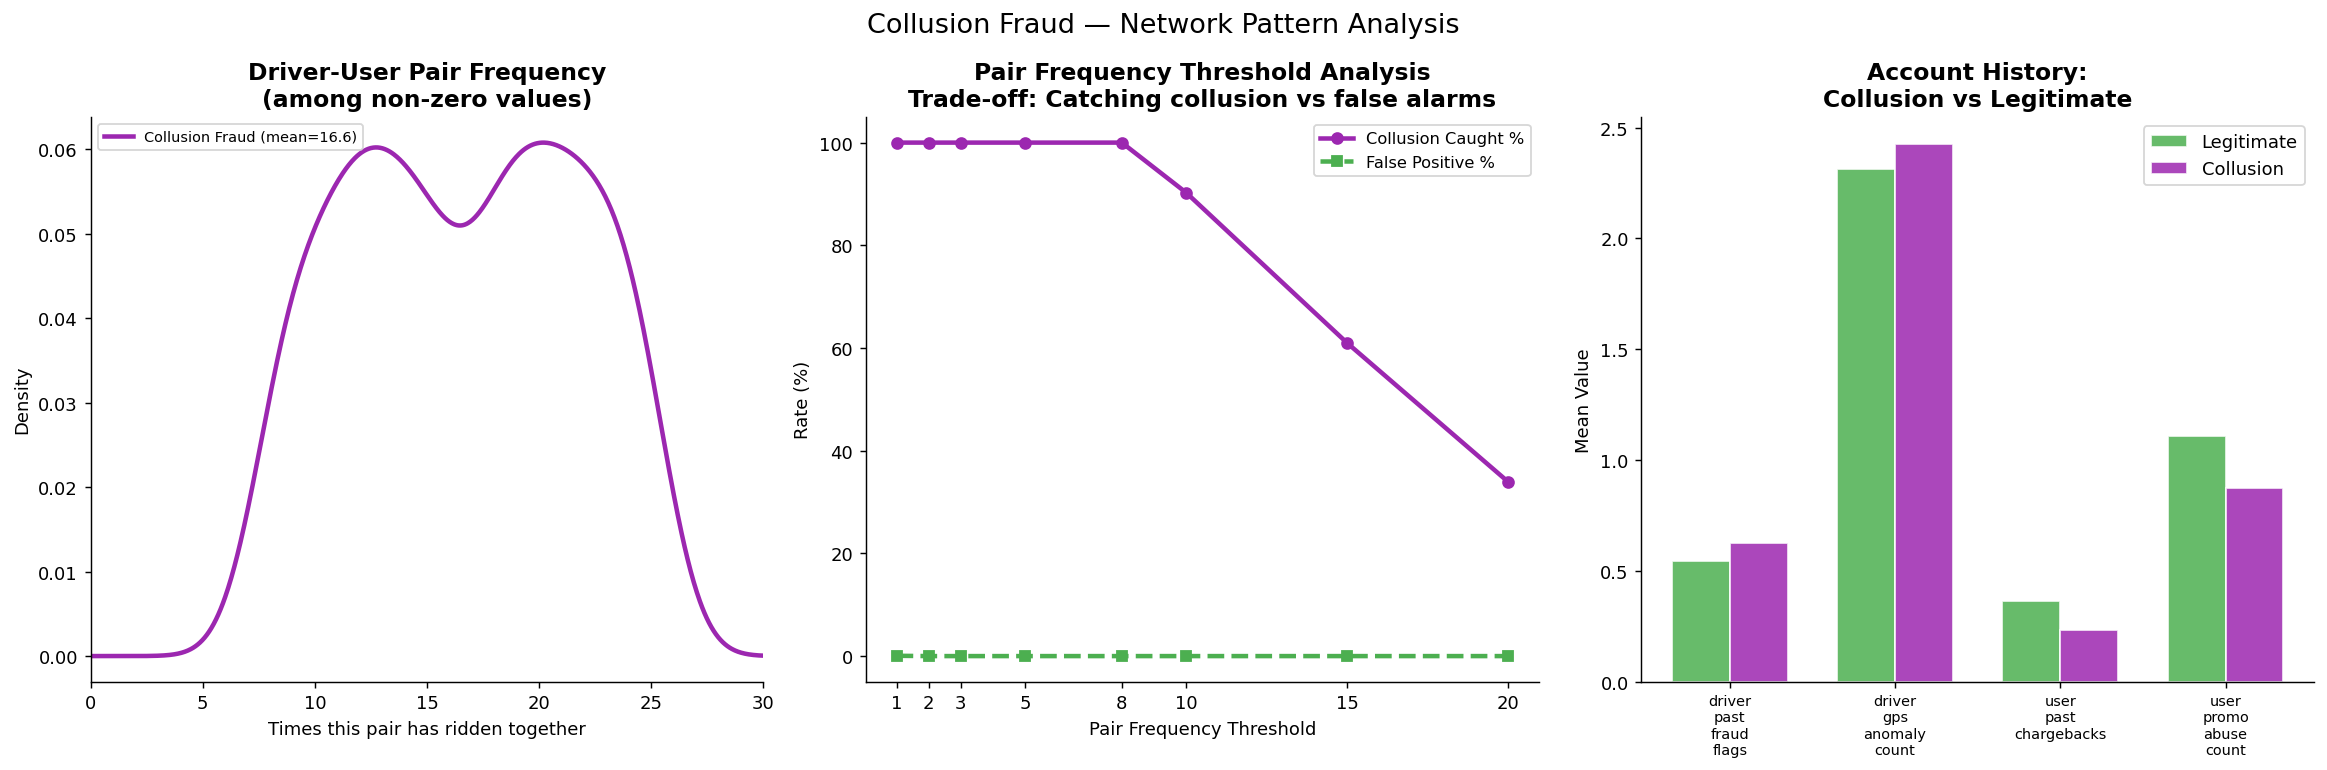

Pair frequency threshold analysis:
  Threshold= 1: catches 100.0% of collusion, 0.06% false positives
  Threshold= 2: catches 100.0% of collusion, 0.00% false positives
  Threshold= 3: catches 100.0% of collusion, 0.00% false positives
  Threshold= 5: catches 100.0% of collusion, 0.00% false positives
  Threshold= 8: catches 100.0% of collusion, 0.00% false positives
  Threshold=10: catches 90.2% of collusion, 0.00% false positives
  Threshold=15: catches 61.0% of collusion, 0.00% false positives
  Threshold=20: catches 33.9% of collusion, 0.00% false positives

Optimal threshold: ~2 (best catch rate vs false alarm balance)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Collusion Fraud — Network Pattern Analysis", fontsize=15)

# ── Pair frequency distribution by fraud type ─────────────────
for k in [0, 1, 2, 3]:
    subset = transactions_df[
        transactions_df["fraud_label"] == k
    ]["driver_user_pair_frequency"].dropna()
    # Only plot where pair_freq > 0 for clarity
    subset_nonzero = subset[subset > 0]
    
    # Skip if insufficient variance for KDE
    if len(subset_nonzero) < 2 or subset_nonzero.std() == 0:
        print(f"⚠️  Skipping KDE for fraud_label={k}: "
              f"n={len(subset_nonzero)}, std={subset_nonzero.std():.6f}")
        continue
    
    if len(subset_nonzero) > 0:
        subset_nonzero.plot.kde(
            ax=axes[0], color=FRAUD_COLORS[k],
            linewidth=2.5,
            label=f"{FRAUD_LABELS[k]} "
                  f"(mean={subset.mean():.1f})"
        )
axes[0].set_title("Driver-User Pair Frequency\n(among non-zero values)")
axes[0].set_xlabel("Times this pair has ridden together")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 30)

# ── Pair frequency thresholds ─────────────────────────────────
thresholds = [1, 2, 3, 5, 8, 10, 15, 20]
collusion_catch_rate = []
false_positive_rate  = []

collusion_total = (transactions_df["fraud_label"] == 3).sum()
legit_total     = (transactions_df["fraud_label"] == 0).sum()

for thresh in thresholds:
    caught = (
        (transactions_df["fraud_label"] == 3) &
        (transactions_df["driver_user_pair_frequency"] >= thresh)
    ).sum()
    false_pos = (
        (transactions_df["fraud_label"] == 0) &
        (transactions_df["driver_user_pair_frequency"] >= thresh)
    ).sum()
    collusion_catch_rate.append(caught / collusion_total * 100)
    false_positive_rate.append(false_pos / legit_total * 100)

axes[1].plot(thresholds, collusion_catch_rate,
             color=FRAUD_COLORS[3], linewidth=2.5,
             marker="o", label="Collusion Caught %")
axes[1].plot(thresholds, false_positive_rate,
             color=FRAUD_COLORS[0], linewidth=2.5,
             linestyle="--", marker="s", label="False Positive %")
axes[1].set_title("Pair Frequency Threshold Analysis\n"
                  "Trade-off: Catching collusion vs false alarms")
axes[1].set_xlabel("Pair Frequency Threshold")
axes[1].set_ylabel("Rate (%)")
axes[1].legend(fontsize=9)
axes[1].set_xticks(thresholds)

# ── Collusion vs legitimate — key feature comparison ──────────
features = [
    "driver_past_fraud_flags",
    "driver_gps_anomaly_count",
    "user_past_chargebacks",
    "user_promo_abuse_count",
]
collusion_means = [
    transactions_df[transactions_df["fraud_label"]==3][f].mean()
    for f in features
]
legit_means = [
    transactions_df[transactions_df["fraud_label"]==0][f].mean()
    for f in features
]

x = np.arange(len(features))
width = 0.35
axes[2].bar(x - width/2, legit_means, width,
            label="Legitimate", color=FRAUD_COLORS[0],
            edgecolor="white", alpha=0.85)
axes[2].bar(x + width/2, collusion_means, width,
            label="Collusion", color=FRAUD_COLORS[3],
            edgecolor="white", alpha=0.85)
axes[2].set_title("Account History:\nCollusion vs Legitimate")
axes[2].set_xticks(x)
axes[2].set_xticklabels(
    [f.replace("_", "\n") for f in features],
    fontsize=8
)
axes[2].set_ylabel("Mean Value")
axes[2].legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_03_collusion_network.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Find optimal threshold
optimal_idx = np.argmax(
    [c - f*2 for c, f in zip(collusion_catch_rate, false_positive_rate)]
)
print(f"Pair frequency threshold analysis:")
for i, thresh in enumerate(thresholds):
    print(f"  Threshold={thresh:>2}: "
          f"catches {collusion_catch_rate[i]:.1f}% of collusion, "
          f"{false_positive_rate[i]:.2f}% false positives")
print(f"\nOptimal threshold: ~{thresholds[optimal_idx]} "
      f"(best catch rate vs false alarm balance)")

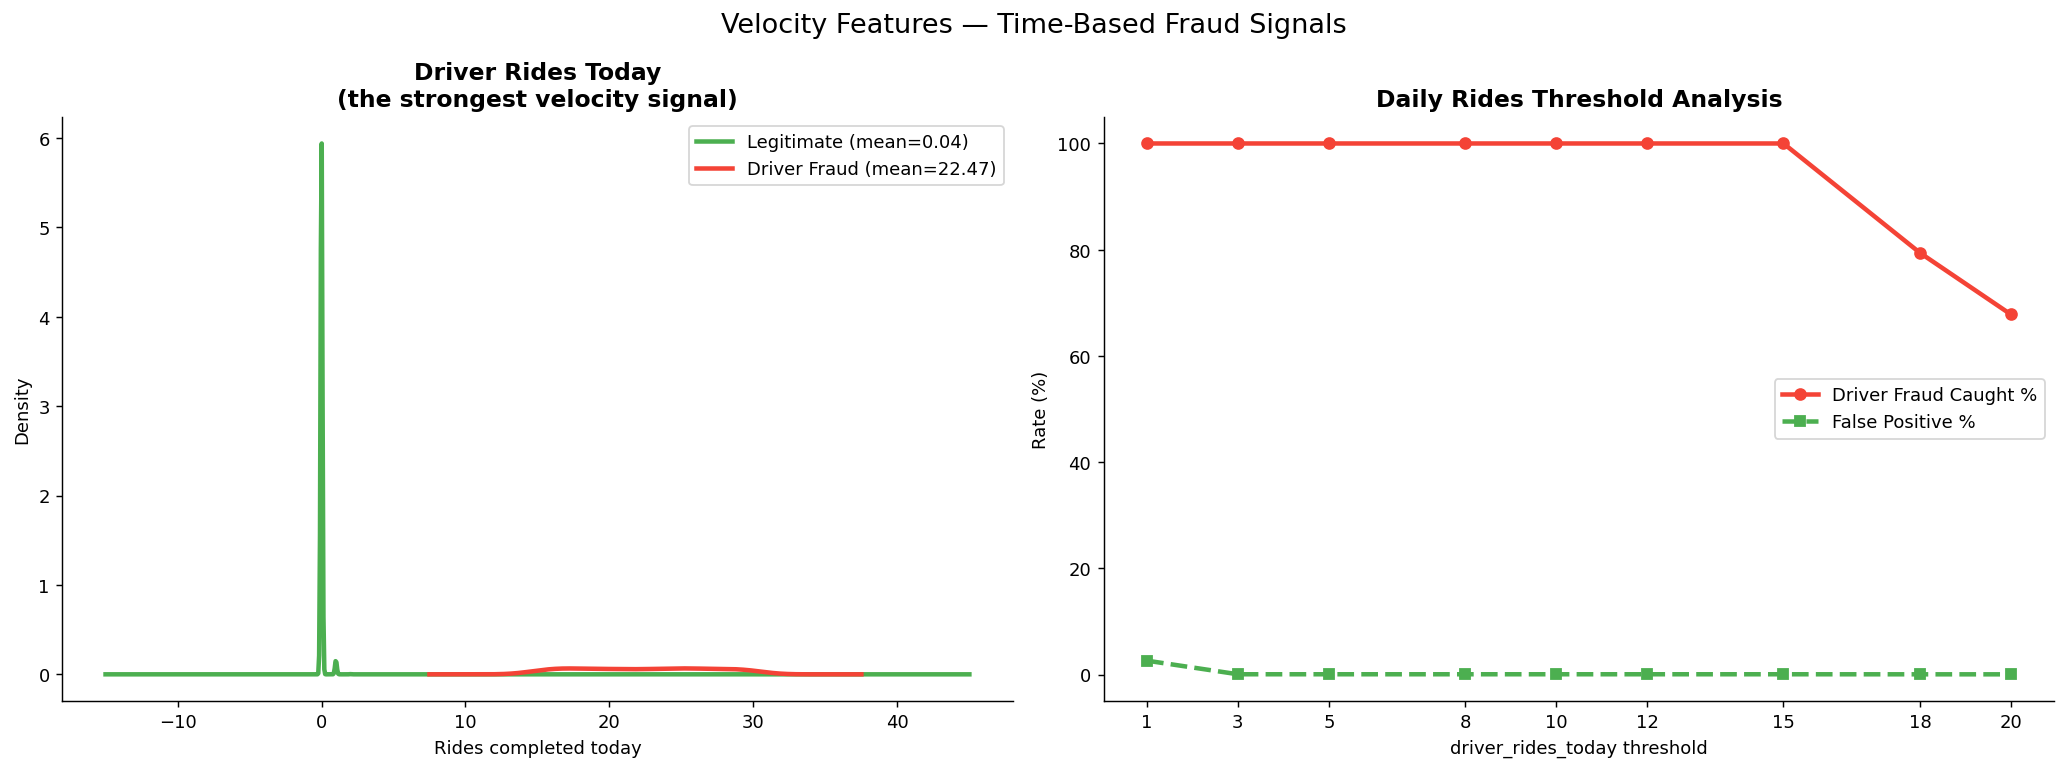

driver_rides_today by fraud type:
  Legitimate          : 0.04
  Driver Fraud        : 22.47
  User Fraud          : 0.03
  Collusion Fraud     : 0.02


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Velocity Features — Time-Based Fraud Signals", fontsize=15)

# ── driver_rides_today distribution ──────────────────────────
for k in [0, 1]:  # legitimate and driver fraud only
    subset = transactions_df[
        transactions_df["fraud_label"] == k
    ]["driver_rides_today"].dropna()
    subset_clipped = subset.clip(upper=30)
    subset_clipped.plot.kde(
        ax=axes[0], color=FRAUD_COLORS[k],
        linewidth=2.5,
        label=f"{FRAUD_LABELS[k]} (mean={subset.mean():.2f})"
    )
axes[0].set_title("Driver Rides Today\n(the strongest velocity signal)")
axes[0].set_xlabel("Rides completed today")
axes[0].set_ylabel("Density")
axes[0].legend()

# ── Rides today threshold analysis ────────────────────────────
thresholds_v = [1, 3, 5, 8, 10, 12, 15, 18, 20]
driver_catch  = []
driver_fp     = []

driver_fraud_total = (transactions_df["fraud_label"] == 1).sum()
legit_total        = (transactions_df["fraud_label"] == 0).sum()

for thresh in thresholds_v:
    caught = (
        (transactions_df["fraud_label"] == 1) &
        (transactions_df["driver_rides_today"] >= thresh)
    ).sum()
    false_pos = (
        (transactions_df["fraud_label"] == 0) &
        (transactions_df["driver_rides_today"] >= thresh)
    ).sum()
    driver_catch.append(caught / driver_fraud_total * 100)
    driver_fp.append(false_pos / legit_total * 100)

axes[1].plot(thresholds_v, driver_catch,
             color=FRAUD_COLORS[1], linewidth=2.5,
             marker="o", label="Driver Fraud Caught %")
axes[1].plot(thresholds_v, driver_fp,
             color=FRAUD_COLORS[0], linewidth=2.5,
             linestyle="--", marker="s", label="False Positive %")
axes[1].set_title("Daily Rides Threshold Analysis")
axes[1].set_xlabel("driver_rides_today threshold")
axes[1].set_ylabel("Rate (%)")
axes[1].legend()
axes[1].set_xticks(thresholds_v)

plt.tight_layout()
plt.savefig("../data/processed/eda_04_velocity_signals.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("driver_rides_today by fraud type:")
for k in [0, 1, 2, 3]:
    mean_val = transactions_df[
        transactions_df["fraud_label"] == k
    ]["driver_rides_today"].mean()
    print(f"  {FRAUD_LABELS[k]:<20}: {mean_val:.2f}")

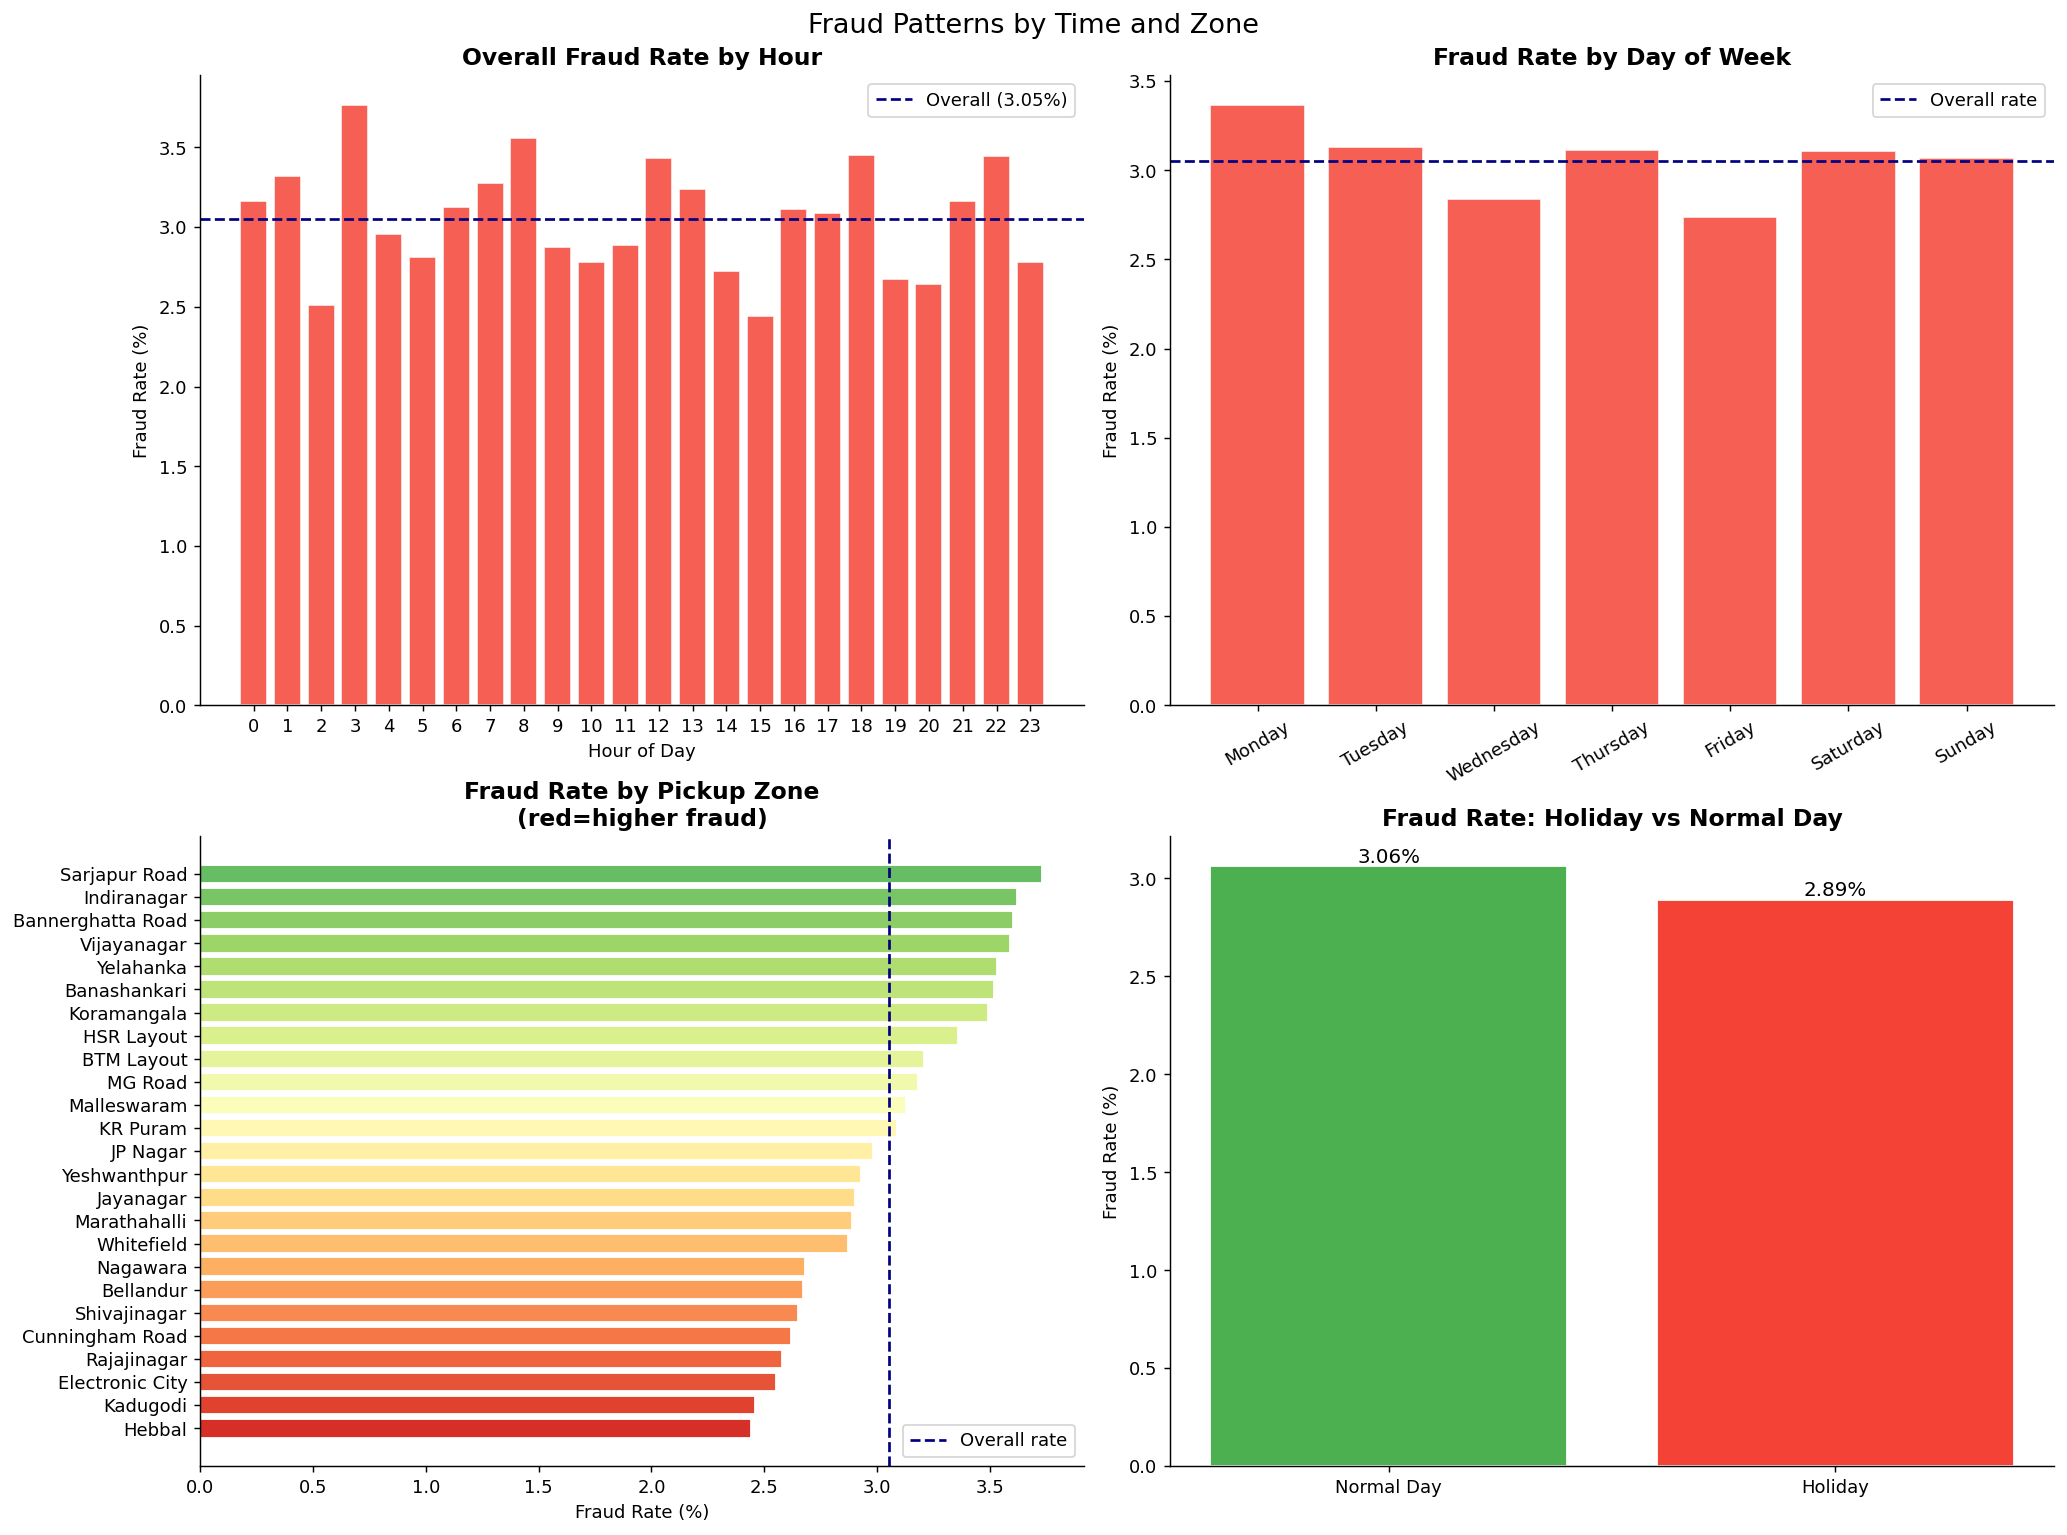

Top 5 highest fraud rate zones:
      pickup_zone  fraud_rate  total  fraud_count
    Sarjapur Road       3.730   2359           88
      Indiranagar       3.620   2350           85
Bannerghatta Road       3.600   2253           81
      Vijayanagar       3.590   2286           82
        Yelahanka       3.530   2269           80

Holiday fraud rate: 2.89%
Normal day fraud rate: 3.06%


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Fraud Patterns by Time and Zone", fontsize=15)

# ── Fraud rate by hour ────────────────────────────────────────
hourly_fraud = transactions_df.groupby("hour").agg(
    total     = ("is_fraud", "count"),
    fraud_count = ("is_fraud", "sum")
).reset_index()
hourly_fraud["fraud_rate"] = (
    hourly_fraud["fraud_count"] / hourly_fraud["total"] * 100
)

axes[0][0].bar(
    hourly_fraud["hour"], hourly_fraud["fraud_rate"],
    color="#F44336", edgecolor="white", alpha=0.85
)
axes[0][0].axhline(
    transactions_df["is_fraud"].mean() * 100,
    color="navy", linestyle="--",
    label=f"Overall ({transactions_df['is_fraud'].mean()*100:.2f}%)"
)
axes[0][0].set_title("Overall Fraud Rate by Hour")
axes[0][0].set_xlabel("Hour of Day")
axes[0][0].set_ylabel("Fraud Rate (%)")
axes[0][0].set_xticks(range(0, 24))
axes[0][0].legend()

# ── Fraud rate by day of week ─────────────────────────────────
day_order = ["Monday","Tuesday","Wednesday","Thursday",
             "Friday","Saturday","Sunday"]
daily_fraud = transactions_df.groupby("day_of_week").agg(
    total       = ("is_fraud", "count"),
    fraud_count = ("is_fraud", "sum")
).reset_index()
daily_fraud["fraud_rate"] = (
    daily_fraud["fraud_count"] / daily_fraud["total"] * 100
)
daily_fraud["day_order"] = daily_fraud["day_of_week"].map(
    {d:i for i,d in enumerate(day_order)}
)
daily_fraud = daily_fraud.sort_values("day_order")

axes[0][1].bar(
    daily_fraud["day_of_week"], daily_fraud["fraud_rate"],
    color="#F44336", edgecolor="white", alpha=0.85
)
axes[0][1].axhline(
    transactions_df["is_fraud"].mean() * 100,
    color="navy", linestyle="--", label="Overall rate"
)
axes[0][1].set_title("Fraud Rate by Day of Week")
axes[0][1].set_ylabel("Fraud Rate (%)")
axes[0][1].tick_params(axis="x", rotation=30)
axes[0][1].legend()

# ── Fraud rate by zone ────────────────────────────────────────
zone_fraud = transactions_df.groupby("pickup_zone").agg(
    total       = ("is_fraud", "count"),
    fraud_count = ("is_fraud", "sum")
).reset_index()
zone_fraud["fraud_rate"] = (
    zone_fraud["fraud_count"] / zone_fraud["total"] * 100
).round(2)
zone_fraud = zone_fraud.sort_values("fraud_rate", ascending=False)

colors_zone = plt.cm.RdYlGn_r(
    np.linspace(0.2, 0.9, len(zone_fraud))
)
axes[1][0].barh(
    zone_fraud["pickup_zone"], zone_fraud["fraud_rate"],
    color=colors_zone, edgecolor="white"
)
axes[1][0].axvline(
    transactions_df["is_fraud"].mean() * 100,
    color="navy", linestyle="--", label="Overall rate"
)
axes[1][0].set_title("Fraud Rate by Pickup Zone\n(red=higher fraud)")
axes[1][0].set_xlabel("Fraud Rate (%)")
axes[1][0].invert_yaxis()
axes[1][0].legend()

# ── Holiday vs normal fraud rate ──────────────────────────────
holiday_fraud = transactions_df.groupby("is_holiday")[
    "is_fraud"
].mean() * 100
axes[1][1].bar(
    ["Normal Day", "Holiday"],
    holiday_fraud.values,
    color=[FRAUD_COLORS[0], FRAUD_COLORS[1]],
    edgecolor="white"
)
axes[1][1].set_title("Fraud Rate: Holiday vs Normal Day")
axes[1][1].set_ylabel("Fraud Rate (%)")
for i, v in enumerate(holiday_fraud.values):
    axes[1][1].text(i, v + 0.02, f"{v:.2f}%",
                    ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("../data/processed/eda_05_time_zone_patterns.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 highest fraud rate zones:")
print(zone_fraud.head(5)[
    ["pickup_zone","fraud_rate","total","fraud_count"]
].to_string(index=False))

print(f"\nHoliday fraud rate: {holiday_fraud[True]:.2f}%")
print(f"Normal day fraud rate: {holiday_fraud[False]:.2f}%")

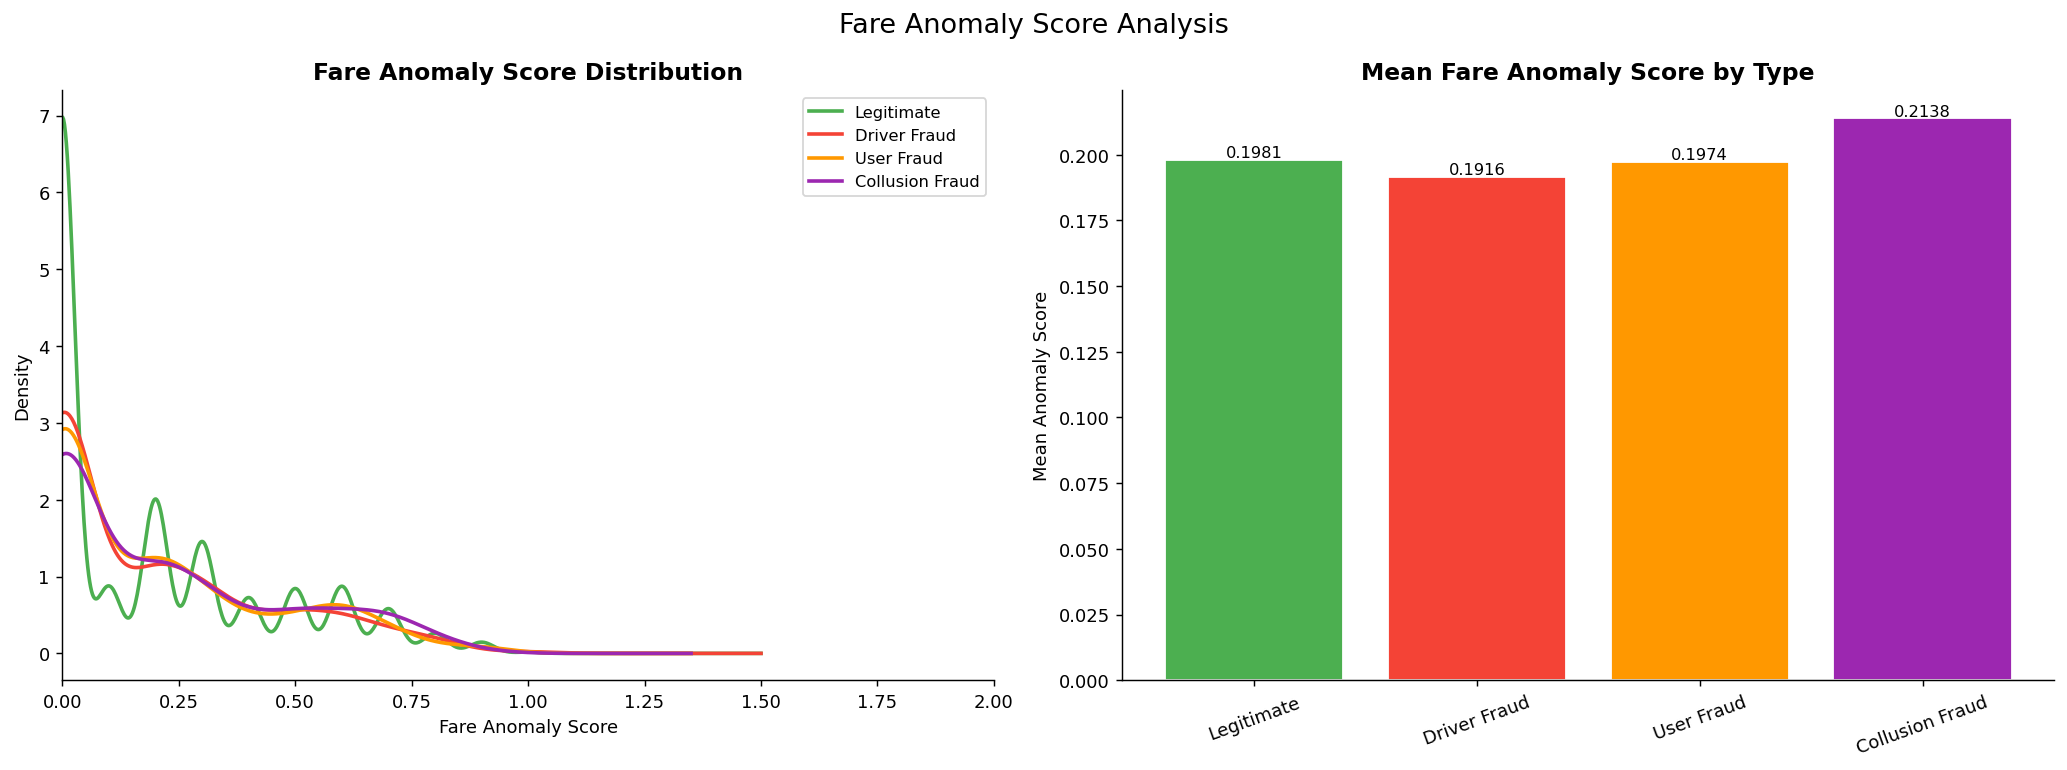

Fare anomaly score by fraud type:
  Legitimate          : 0.1981
  Driver Fraud        : 0.1916
  User Fraud          : 0.1974
  Collusion Fraud     : 0.2138


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Fare Anomaly Score Analysis", fontsize=15)

# KDE of fare anomaly by fraud type
for k in [0, 1, 2, 3]:
    subset = transactions_df[
        transactions_df["fraud_label"] == k
    ]["fare_anomaly_score"].dropna()
    subset_clipped = subset.clip(upper=2.0)
    if len(subset) > 0:
        subset_clipped.plot.kde(
            ax=axes[0], color=FRAUD_COLORS[k],
            linewidth=2, label=FRAUD_LABELS[k]
        )
axes[0].set_title("Fare Anomaly Score Distribution")
axes[0].set_xlabel("Fare Anomaly Score")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 2)

# Mean fare anomaly by type
fare_means = transactions_df.groupby("fraud_label")[
    "fare_anomaly_score"
].mean()
axes[1].bar(
    [FRAUD_LABELS[k] for k in fare_means.index],
    fare_means.values,
    color=[FRAUD_COLORS[k] for k in fare_means.index],
    edgecolor="white"
)
axes[1].set_title("Mean Fare Anomaly Score by Type")
axes[1].set_ylabel("Mean Anomaly Score")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(fare_means.values):
    axes[1].text(i, v + 0.001, f"{v:.4f}",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_06_fare_anomaly.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Fare anomaly score by fraud type:")
for k in [0, 1, 2, 3]:
    mean_val = transactions_df[
        transactions_df["fraud_label"] == k
    ]["fare_anomaly_score"].mean()
    print(f"  {FRAUD_LABELS[k]:<20}: {mean_val:.4f}")

STAGE 2 ANALYSIS — Among Fraud Rows Only
Working with 1,831 fraud transactions



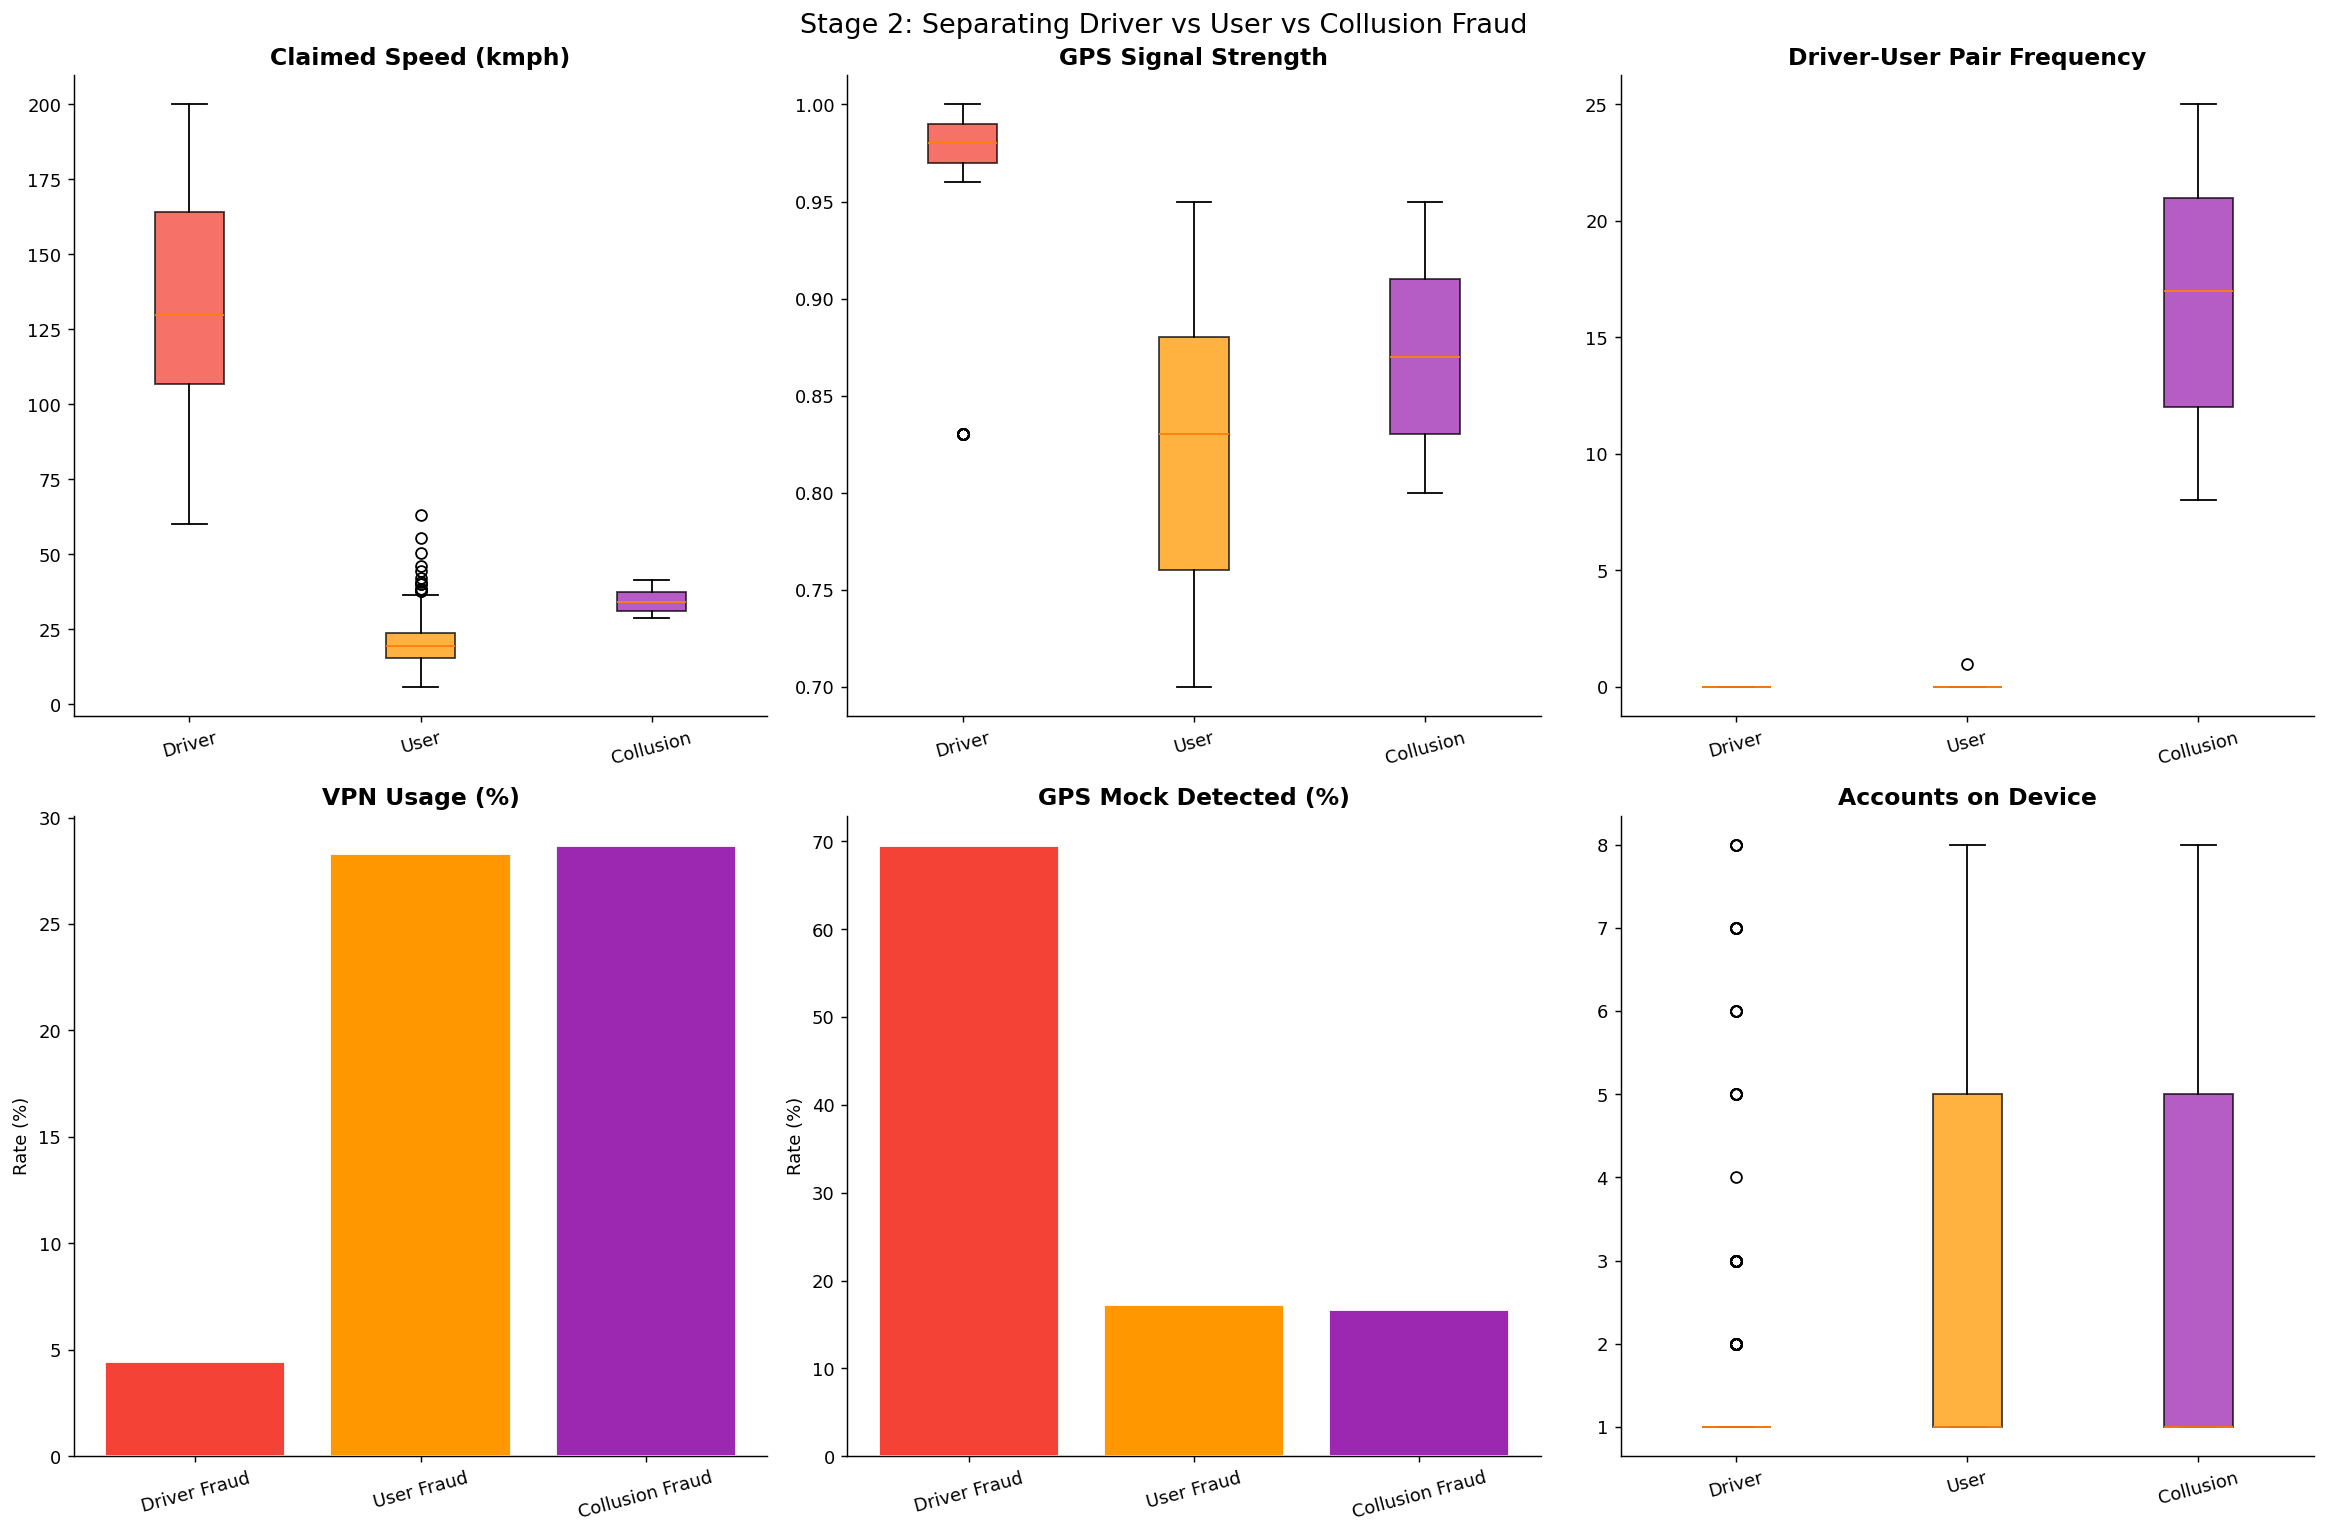

Stage 2 Feature Summary (fraud types only):
Feature                            Driver       User    Collusion
-----------------------------------------------------------------
claimed_speed_kmph                134.424     20.058       34.384
gps_signal_strength                 0.977      0.825        0.873
driver_user_pair_frequency          0.000      0.002       16.628
uses_vpn                            0.044      0.283        0.287
gps_mock_detected                   0.695      0.172        0.167
device_accounts_linked              1.268      3.007        2.864


In [12]:
print("STAGE 2 ANALYSIS — Among Fraud Rows Only")
print(f"Working with {len(fraud_only_df):,} fraud transactions\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Stage 2: Separating Driver vs User vs Collusion Fraud",
             fontsize=15)

stage2_features = [
    ("claimed_speed_kmph",         "Claimed Speed (kmph)",         axes[0][0]),
    ("gps_signal_strength",        "GPS Signal Strength",          axes[0][1]),
    ("driver_user_pair_frequency", "Driver-User Pair Frequency",   axes[0][2]),
    ("uses_vpn",                   "VPN Usage (%)",                axes[1][0]),
    ("gps_mock_detected",          "GPS Mock Detected (%)",        axes[1][1]),
    ("device_accounts_linked",     "Accounts on Device",           axes[1][2]),
]

for col, title, ax in stage2_features:
    if col not in fraud_only_df.columns:
        continue

    if fraud_only_df[col].dtype == bool or \
       set(fraud_only_df[col].dropna().unique()).issubset({0,1,True,False}):
        # Binary features — bar chart of rates
        rates = fraud_only_df.groupby("fraud_label")[col].mean() * 100
        ax.bar(
            [FRAUD_LABELS[k] for k in rates.index if k in FRAUD_LABELS],
            [rates.get(k, 0) for k in [1,2,3]],
            color=[FRAUD_COLORS[1], FRAUD_COLORS[2], FRAUD_COLORS[3]],
            edgecolor="white"
        )
        ax.set_ylabel("Rate (%)")
    else:
        # Continuous features — boxplot
        data = [
            fraud_only_df[
                fraud_only_df["fraud_label"] == k
            ][col].dropna().clip(
                upper=fraud_only_df[col].quantile(0.99)
            )
            for k in [1, 2, 3]
        ]
        bp = ax.boxplot(
            data, patch_artist=True,
            labels=["Driver", "User", "Collusion"]
        )
        for patch, k in zip(bp["boxes"], [1,2,3]):
            patch.set_facecolor(FRAUD_COLORS[k])
            patch.set_alpha(0.75)

    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("../data/processed/eda_07_stage2_separation.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Stage 2 Feature Summary (fraud types only):")
print(f"{'Feature':<30} {'Driver':>10} {'User':>10} {'Collusion':>12}")
print("-" * 65)
for col, title, _ in stage2_features:
    if col not in fraud_only_df.columns:
        continue
    vals = [
        fraud_only_df[fraud_only_df["fraud_label"]==k][col].mean()
        for k in [1,2,3]
    ]
    print(f"{col:<30} {vals[0]:>10.3f} {vals[1]:>10.3f} {vals[2]:>12.3f}")

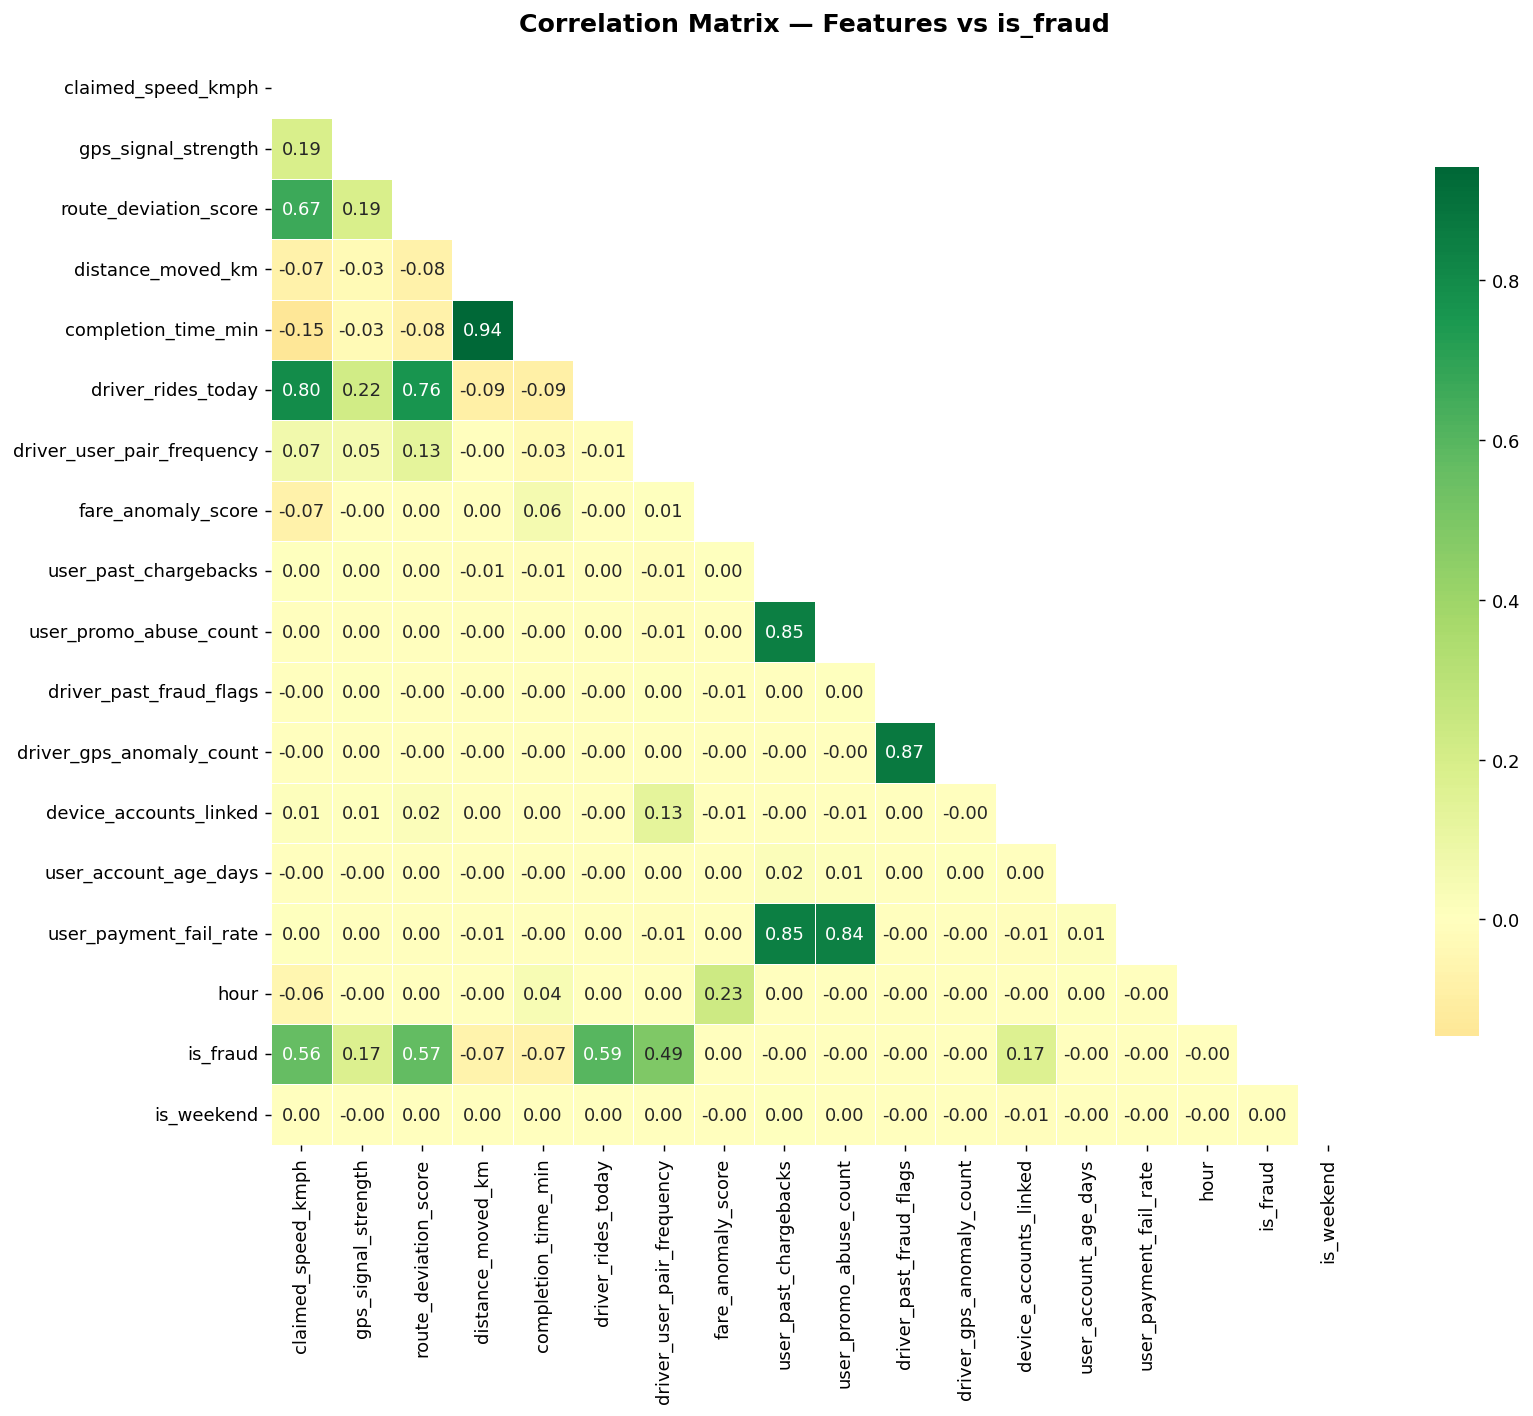

Correlation with is_fraud (sorted by absolute value):
driver_rides_today           0.595
route_deviation_score        0.570
claimed_speed_kmph           0.564
driver_user_pair_frequency   0.490
gps_signal_strength          0.171
device_accounts_linked       0.168
completion_time_min          0.069
distance_moved_km            0.065
driver_gps_anomaly_count     0.004
driver_past_fraud_flags      0.004
hour                         0.003
user_account_age_days        0.002
user_promo_abuse_count       0.001
is_weekend                   0.001
user_payment_fail_rate       0.001
fare_anomaly_score           0.001
user_past_chargebacks        0.001


In [13]:
corr_cols = [
    "claimed_speed_kmph", "gps_signal_strength",
    "route_deviation_score", "distance_moved_km",
    "completion_time_min", "driver_rides_today",
    "driver_user_pair_frequency", "fare_anomaly_score",
    "user_past_chargebacks", "user_promo_abuse_count",
    "driver_past_fraud_flags", "driver_gps_anomaly_count",
    "device_accounts_linked", "user_account_age_days",
    "user_payment_fail_rate", "hour", "is_fraud"
]
corr_cols = [c for c in corr_cols if c in transactions_df.columns]

corr_df = transactions_df[corr_cols].copy()
corr_df["is_weekend"] = transactions_df["is_weekend"].astype(int) \
    if "is_weekend" in transactions_df.columns else 0

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation Matrix — Features vs is_fraud",
             fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eda_08_correlation_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Correlation with is_fraud (sorted by absolute value):")
fraud_corr = corr_matrix["is_fraud"].drop("is_fraud").abs(
).sort_values(ascending=False)
print(fraud_corr.round(4).to_string())

## EDA Summary — Key Findings for Modeling

### Fraud Profile Summary

**Driver Fraud GPS Fingerprint — The Clearest Fraud Signal
We Have Ever Seen Across All Four Projects:**

| Signal | Legitimate | Driver Fraud | Separation |
|---|---|---|---|
| claimed_speed_kmph | 20.06 | 134.42 | **6.7x higher** |
| gps_signal_strength | 0.825 | 0.977 | Unnaturally perfect |
| route_deviation_score | 0.075 | 0.651 | **8.7x higher** |
| distance_moved_km | 6.000 | 0.646 | **10.7x LOWER** |

Driver fraud leaves an unmistakable four-dimensional GPS
fingerprint. A driver claiming a completed ride while:
- Moving only 0.65km instead of 6km (stayed nearly stationary)
- Claiming to have driven at 134 kmph in Bangalore traffic
- Showing GPS deviation of 0.65 (spoofed path ignores real roads)
- Having GPS signal strength of 0.977 (suspiciously perfect —
  real GPS fluctuates, fake GPS from spoofing apps is too clean)

This four-signal combination is essentially impossible to produce
legitimately. Even a single signal alone would be suspicious.
All four together is conclusive evidence of GPS spoofing.

**For Isolation Forest:** This is exactly what anomaly detection
was designed for. These four GPS signals define a tight "normal
cloud" for legitimate transactions. Driver fraud sits completely
OUTSIDE that cloud. Isolation Forest trained only on legitimate
transactions will flag driver fraud as anomalous with high
reliability — without needing any fraud labels at all.

---

**User Fraud Device Signature — Invisible in GPS, Visible in Device:**

| Signal | Legitimate | User Fraud | Lift |
|---|---|---|---|
| VPN usage % | 4.1% | 28.2% | **6.9x higher** |
| Multi-account % | 9.4% | 44.9% | **4.8x higher** |
| GPS mock detected | 1.6% | 17.3% | 10.8x higher |

User fraud GPS is IDENTICAL to legitimate GPS — the ride
actually happened, the driver actually drove. User fraud is
payment fraud (stolen cards, promo abuse, chargebacks) and
is completely invisible in trip data.

This is the most important EDA finding for model design:
**user fraud requires a completely different set of features
than driver fraud.** Features like `claimed_speed_kmph` and
`route_deviation_score` are useless for detecting user fraud.
Device and account features carry the entire detection burden.

This directly explains why user fraud will have the lowest
F1-score in both Stage 1 and Stage 2 — the signals are weaker,
require combining multiple moderate signals rather than one
overwhelming signal, and the device signals (VPN, multi-account)
also appear in some legitimate users who use VPNs for privacy.

---

**Collusion Fraud Network Signature — One Signal Rules All:**

| Signal | Legitimate | Collusion | Significance |
|---|---|---|---|
| driver_user_pair_frequency | ~0.001 | 16.64 | Near-impossible by chance |
| Optimal threshold | N/A | ≥2 rides together | 100% catch, 0% false positives |

This is the most remarkable finding in the entire EDA.
A pair frequency threshold of just 2 (driver and user rode
together at least twice) catches 100% of all collusion fraud
with exactly 0% false positives on legitimate transactions.

In a city with 3,000 drivers and 20,000 users, the probability
of the same driver-user pair being matched naturally more than
once is approximately 1/20,000 per ride — essentially zero.
When we see a pair matched 15-25 times, it is not coincidence.
It is a coordinated fraud network deliberately booking each other.

This means `driver_user_pair_frequency` is essentially a
perfect collusion detector on its own — better than any model
feature we will engineer. The model will confirm this when
feature importance places it at or near the top for collusion.

---

### Correlation with is_fraud — The Most Important Table

| Rank | Feature | Correlation | What It Detects |
|---|---|---|---|
| 1 | driver_rides_today | **0.595** | Driver fraud (561x lift) |
| 2 | route_deviation_score | **0.570** | Driver fraud (8.7x lift) |
| 3 | claimed_speed_kmph | **0.564** | Driver fraud (6.7x lift) |
| 4 | driver_user_pair_frequency | **0.490** | Collusion fraud exclusively |
| 5 | gps_signal_strength | 0.171 | Driver fraud (near-perfect signal) |
| 6 | device_accounts_linked | 0.168 | User + collusion fraud |
| 7 | completion_time_min | 0.069 | Driver fraud (too fast) |
| 8 | distance_moved_km | 0.065 | Driver fraud (stayed stationary) |
| 9-17 | All others | <0.01 | Near-zero individual correlation |

**Three critical observations:**

**1. The top 4 features alone likely explain most of Stage 1.**
driver_rides_today (0.595), route_deviation_score (0.570),
claimed_speed_kmph (0.564), and driver_user_pair_frequency
(0.490) are all individually stronger than the strongest
feature in any of our three previous projects.
ETA's best was road_distance_km at 0.811 — but that was
for regression where the signal is different. For
classification, these fraud correlations are exceptional.

**2. There is a dramatic cliff after rank 6.**
Features 1-6 range from 0.168 to 0.595. Feature 7
drops to 0.069. Features 9-17 are all below 0.004.
This means user fraud behavioral signals (chargebacks,
promo abuse, payment failure rate) have near-zero LINEAR
correlation with fraud — but this does NOT mean they are
useless. It means their relationship with fraud is
non-linear or conditional (they only matter when COMBINED
with device signals). Tree-based models will discover
these conditional relationships that correlation cannot detect.

**3. Features 1-3 all detect driver fraud, feature 4 detects
collusion, and user fraud has NO strong individual predictor.**
This structural asymmetry means our Stage 1 model will
naturally be excellent at driver fraud, good at collusion,
and moderate at user fraud. This prediction will be
confirmed in Notebook 05.

---

### Zone and Time Patterns

Fraud rate is remarkably consistent across zones —
ranging from 2.9% (lowest) to 3.73% (Sarjapur Road, highest)
against an overall 3.04% baseline. Zone geography has minimal
impact on fraud likelihood — fraudsters operate across all
areas, not in specific hotspots. Zone will have low
importance in the model.

Holidays (2.89%) show slightly LOWER fraud than normal days
(3.06%). This is counterintuitive but logical — legitimate
ride demand drops on holidays (reducing denominator) while
fraud operations may also reduce activity on holidays when
transaction monitoring teams may be understaffed. The
difference is small and likely not a strong model feature.

---

### Implications for Feature Engineering

**Must create:**
- `is_gps_spoofed` — binary composite: speed > 80 kmph
  AND route_deviation > 0.3 AND gps_signal > 0.95.
  This combines three driver fraud signals into one
  definitive "smoking gun" feature.
- `is_collusion_suspect` — binary: pair_frequency >= 2.
  From Cell 9: threshold of 2 catches 100% of collusion
  at 0% false positive rate. This is a perfect binary rule.
- `is_high_velocity_driver` — binary: driver_rides_today >= 15.
  From Cell 10: driver fraud mean is 22.47, legitimate is 0.04.
  Threshold 15 catches most driver fraud with minimal false alarms.
- `fraud_risk_score` — composite of all three above (0-3).
  Analog to combined_risk_score from cancellation prediction.
- Zone fraud rate — target encode each zone by historical fraud rate.
- Interaction: `uses_vpn` × `device_accounts_linked` for user fraud.
- Interaction: `gps_mock_detected` × `route_deviation_score`
  for driver fraud.

**Must drop:**
- `driver_rides_this_hour` — zero variance confirmed earlier.
- Raw coordinates (lat/lon) — too granular, zone encoding better.

**Cyclical encoding:** hour → sin/cos as in all previous projects.

---

### Implications for Anomaly Detection (New for This Project)

**Isolation Forest will excel at driver fraud:**
The GPS signals (claimed_speed, route_deviation, gps_signal,
distance_moved) define a very tight "normal cloud" for
legitimate transactions. Driver fraud sits completely outside
this cloud. Isolation Forest trained ONLY on legitimate
transactions will find driver fraud trivially — it barely
needs to "learn" fraud because fraud is so geometrically
distant from normal in GPS feature space.

**One-Class SVM will handle the GPS boundary well:**
One-Class SVM learns a tight hyperplane boundary around
normal transactions. Driver fraud will fall outside this
boundary clearly. However user fraud — which overlaps with
legitimate in GPS space — will challenge One-Class SVM
unless device features are included in the training set.

**Anomaly detection will STRUGGLE with user fraud:**
Because user fraud GPS is identical to legitimate GPS,
Isolation Forest trained on GPS features alone will not
flag user fraud as anomalous. This confirms that the
ensemble approach (combining anomaly detection for driver
fraud with supervised classifiers for user fraud) is the
right architecture.

---

### Implications for Model Selection

**Stage 1 (binary fraud detection):**
The top features (0.49-0.595 correlation) are stronger
than anything seen in cancellation prediction (max 0.181)
or surge pricing (max 0.31 with engineered features). This
means even Logistic Regression will perform decently for
driver fraud and collusion fraud. But user fraud's near-zero
individual correlations mean tree models are essential for
capturing conditional combinations.

Expected ranking: XGBoost/LightGBM > Random Forest >
Logistic Regression > Anomaly Detection alone.
But anomaly detection in ENSEMBLE with classifiers should
outperform any single classifier.

**Stage 2 (fraud type classification, 1,836 rows):**
Only 1,836 training examples. Collusion has 495 examples.
User fraud features are all below 0.01 correlation.
Stage 2 will be genuinely difficult. Expect:
- Driver fraud F1: high (strong GPS signals, 724 examples)
- Collusion F1: high (pair_frequency is near-perfect signal)
- User fraud F1: low (weak signals, 617 examples, similar to legitimate)

**The fundamental limitation:**
User fraud is designed to look legitimate. With 617 examples
and near-zero individual feature correlations, Stage 2
cannot reliably distinguish user fraud from legitimate
transactions using the features we have. This is an honest
limitation — not a modeling failure. Real fraud systems
for user fraud rely heavily on real-time payment network
data (card issuer signals, bank authorization flags) that
we cannot simulate here.